<a href="https://colab.research.google.com/github/Naveen022004/Automated-notification-with-pending-intent/blob/main/Temporal_Deep_Learning_Crop_Yield_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Temporal Deep Learning for Crop Yield Prediction Using Satellite and Environmental Data

**Class Project | Google Colab Ready**

This project predicts crop yield from **temporal satellite/environmental observations** using an **LSTM deep-learning model**. It includes a built-in synthetic dataset so the notebook runs immediately in Google Colab, while also supporting a user-provided CSV dataset.

### Project pipeline
Satellite/environmental time series → preprocessing → sliding temporal sequences → LSTM → yield prediction → evaluation → visualization → saved model

**Important:** The included synthetic data is for demonstration and classroom execution. For a real research result, replace it with a validated agricultural/satellite dataset.

## 1. Learning Objectives

- Understand temporal crop-yield prediction.
- Combine vegetation indices and environmental variables as time-series features.
- Prepare fixed-length sequences for an LSTM.
- Train and evaluate a deep-learning regression model.
- Visualize predicted vs. actual yield and training behavior.
- Save the trained model and preprocessing artifacts for deployment.

In [ ]:
!pip -q install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
GPU available: False


## 2. Dataset Options

**Option A — Run immediately:** use the synthetic dataset generated below.

**Option B — Use your own CSV:** set `USE_CUSTOM_CSV = True` and upload a CSV containing the columns described below.

Recommended columns:

`field_id`, `date`, `ndvi`, `evi`, `ndwi`, `lst_c`, `rainfall_mm`, `soil_moisture`, `yield_t_ha`

Each `field_id` should contain multiple chronological observations. `yield_t_ha` should be the final/field-level crop yield repeated for that field's observations.

In [ ]:
USE_CUSTOM_CSV = False
CUSTOM_CSV_PATH = '/content/crop_yield_timeseries.csv'

FEATURES = ['ndvi', 'evi', 'ndwi', 'lst_c', 'rainfall_mm', 'soil_moisture']
TARGET = 'yield_t_ha'
TIME_STEPS = 8

if USE_CUSTOM_CSV:
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        CUSTOM_CSV_PATH = '/content/' + next(iter(uploaded))
    df = pd.read_csv(CUSTOM_CSV_PATH)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['field_id', 'date']).reset_index(drop=True)
else:
    # Reproducible synthetic agricultural time-series dataset.
    rng = np.random.default_rng(SEED)
    n_fields = 180
    dates = pd.date_range('2018-01-01', periods=12, freq='MS')
    rows = []
    for field_id in range(n_fields):
        base = rng.uniform(0.8, 1.2)
        season = rng.uniform(0.0, 2*np.pi)
        rainfall = np.maximum(0, 70 + 45*np.sin(np.arange(12)/12*2*np.pi + season) + rng.normal(0, 12, 12))
        temp = 25 + 5*np.sin(np.arange(12)/12*2*np.pi + season + 0.8) + rng.normal(0, 1.5, 12)
        soil = np.clip(0.38 + 0.002*rainfall + rng.normal(0, 0.035, 12), 0.12, 0.75)
        ndvi = np.clip(0.25 + 0.55*np.exp(-((np.arange(12)-7)/3.0)**2) * base + 0.0015*rainfall + rng.normal(0, .035, 12), 0, 0.95)
        evi = np.clip(ndvi*0.82 + rng.normal(0, .025, 12), 0, 0.9)
        ndwi = np.clip(0.05 + 0.0025*rainfall + 0.25*(soil-0.35) + rng.normal(0, .025, 12), -0.3, 0.8)
        yield_value = 1.0 + 4.0*ndvi.mean() + 1.2*soil.mean() + 0.006*rainfall.sum() - 0.018*np.maximum(temp-31, 0).sum() + rng.normal(0, .25)
        for i, d in enumerate(dates):
            rows.append([field_id, d, ndvi[i], evi[i], ndwi[i], temp[i], rainfall[i], soil[i], max(0.5, yield_value)])
    df = pd.DataFrame(rows, columns=['field_id','date'] + FEATURES + [TARGET])

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (2160, 9)


,field_id,date,ndvi,evi,ndwi,lst_c,rainfall_mm,soil_moisture,yield_t_ha
0,0,2018-01-01,0.367578,0.308642,0.353823,23.680914,95.865450,0.590362,9.212616
1,0,2018-02-01,0.396489,0.340903,0.300434,19.674567,75.026913,0.542844,9.212616
2,0,2018-03-01,0.342286,0.244246,0.135547,20.582062,18.885140,0.432216,9.212616
3,0,2018-04-01,0.391132,0.312736,0.119058,18.988036,12.651679,0.420382,9.212616
4,0,2018-05-01,0.491670,0.391410,0.148436,23.366962,26.971611,0.508901,9.212616


In [ ]:
# Basic data validation and cleanup
required = ['field_id', 'date'] + FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df[required].copy()
for col in FEATURES + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=FEATURES + [TARGET]).sort_values(['field_id', 'date'])

print('Fields:', df['field_id'].nunique())
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('\nSummary statistics:')
display(df[FEATURES + [TARGET]].describe().round(3))

Fields: 180
Date range: 2018-01-01 to 2018-12-01

Summary statistics:


,ndvi,evi,ndwi,lst_c,rainfall_mm,soil_moisture,yield_t_ha
count,2160.000,2160.000,2160.000,2160.000,2160.000,2160.000,2160.000
mean,0.591,0.484,0.266,24.997,69.812,0.520,8.976
std,0.199,0.165,0.106,3.867,34.065,0.077,0.397
min,0.189,0.126,0.010,15.495,0.000,0.315,7.923
25%,0.422,0.344,0.178,21.713,40.447,0.460,8.705
50%,0.560,0.459,0.268,24.992,70.835,0.520,8.980
75%,0.768,0.626,0.352,28.356,99.378,0.580,9.209
max,0.950,0.827,0.532,34.487,148.028,0.731,10.102


## 3. Exploratory Data Analysis

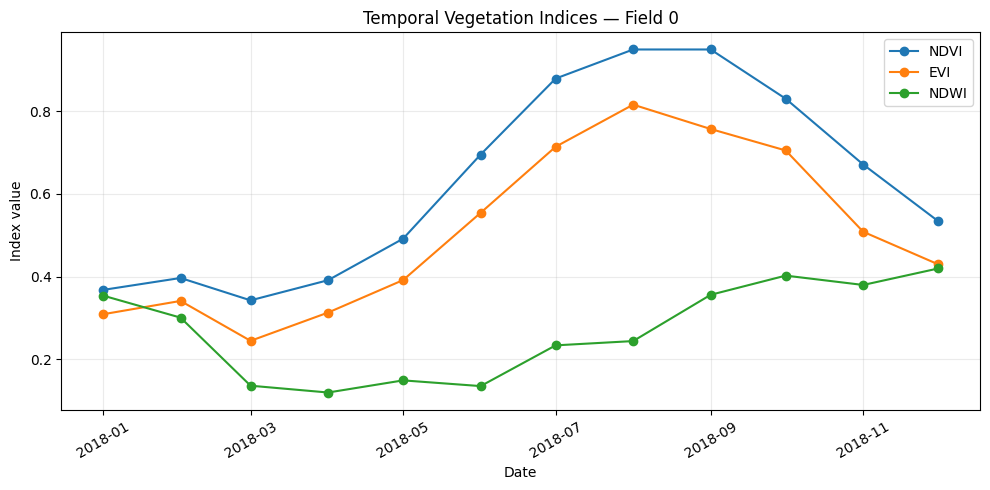

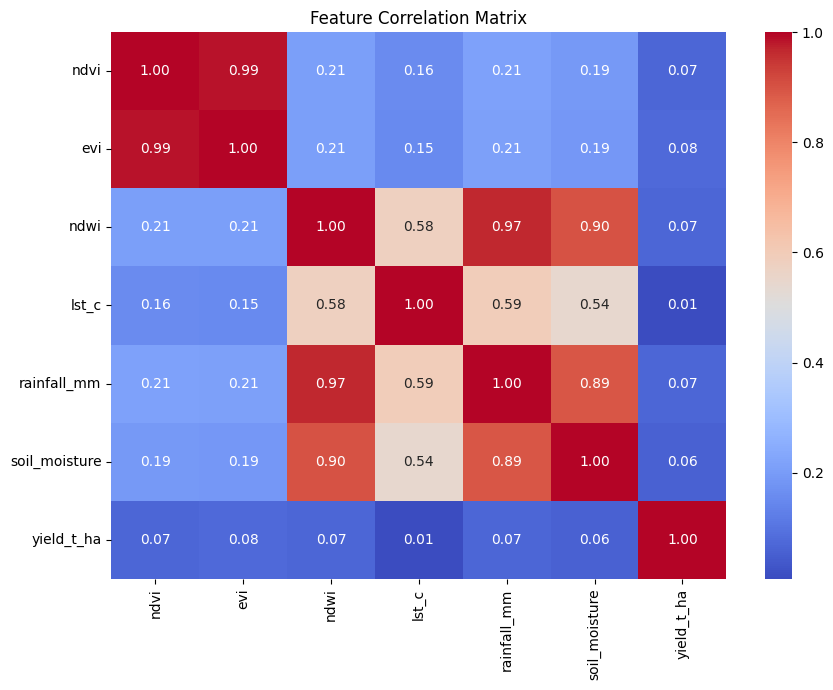

In [ ]:
plt.figure(figsize=(10, 5))
sample_field = df['field_id'].iloc[0]
sample = df[df['field_id'] == sample_field]
plt.plot(sample['date'], sample['ndvi'], marker='o', label='NDVI')
plt.plot(sample['date'], sample['evi'], marker='o', label='EVI')
plt.plot(sample['date'], sample['ndwi'], marker='o', label='NDWI')
plt.title(f'Temporal Vegetation Indices — Field {sample_field}')
plt.xlabel('Date'); plt.ylabel('Index value'); plt.legend(); plt.grid(alpha=.25)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix'); plt.tight_layout(); plt.show()

## 4. Build Temporal Sequences

For each field, the model receives the previous `TIME_STEPS` observations as one sequence. The target is the field's crop yield.

To avoid leakage, fields—not individual rows—are split into train, validation, and test sets.

In [ ]:
fields = df['field_id'].unique()
rng = np.random.default_rng(SEED)
rng.shuffle(fields)

n = len(fields)
train_fields = fields[:int(.70*n)]
val_fields = fields[int(.70*n):int(.85*n)]
test_fields = fields[int(.85*n):]

train_df = df[df.field_id.isin(train_fields)].copy()
val_df = df[df.field_id.isin(val_fields)].copy()
test_df = df[df.field_id.isin(test_fields)].copy()

feature_scaler = StandardScaler()
target_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURES])
target_scaler.fit(train_df[[TARGET]])

def make_sequences(data, feature_scaler, target_scaler, time_steps):
    X, y, ids = [], [], []
    for field_id, g in data.groupby('field_id'):
        g = g.sort_values('date')
        if len(g) < time_steps:
            continue
        X_scaled = feature_scaler.transform(g[FEATURES])
        y_scaled = target_scaler.transform(g[[TARGET]]).ravel()
        # One sequence per field using its latest time_steps observations.
        X.append(X_scaled[-time_steps:])
        y.append(y_scaled[-1])
        ids.append(field_id)
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(ids)

X_train, y_train, id_train = make_sequences(train_df, feature_scaler, target_scaler, TIME_STEPS)
X_val, y_val, id_val = make_sequences(val_df, feature_scaler, target_scaler, TIME_STEPS)
X_test, y_test, id_test = make_sequences(test_df, feature_scaler, target_scaler, TIME_STEPS)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

X_train: (125, 8, 6) y_train: (125,)
X_val:   (28, 8, 6) y_val:   (28,)
X_test:  (27, 8, 6) y_test:  (27,)


## 5. LSTM Model

In [ ]:
model = Sequential([
    Input(shape=(TIME_STEPS, len(FEATURES))),
    LSTM(64, return_sequences=True),
    Dropout(0.20),
    LSTM(32),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 8, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

NameError: name 'EarlyStopping' is not defined

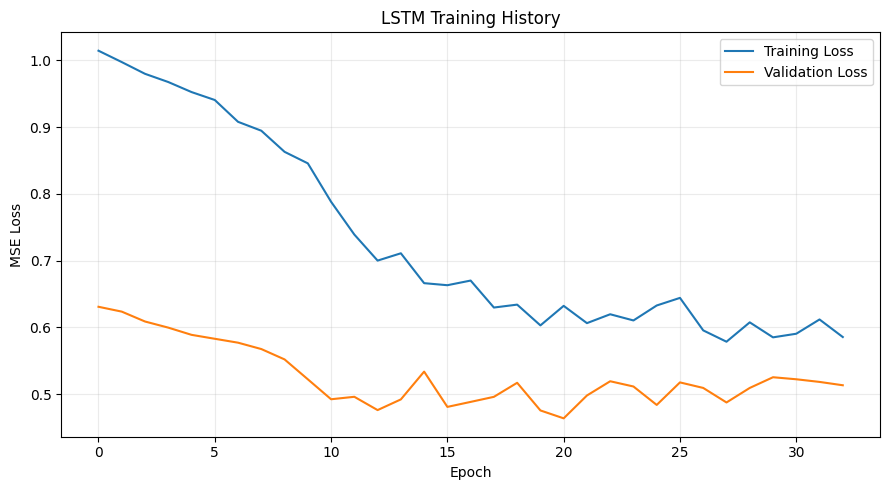

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 6. Model Evaluation

,Metric,Value
0,MAE (t/ha),0.2751
1,RMSE (t/ha),0.3456
2,R²,0.2122


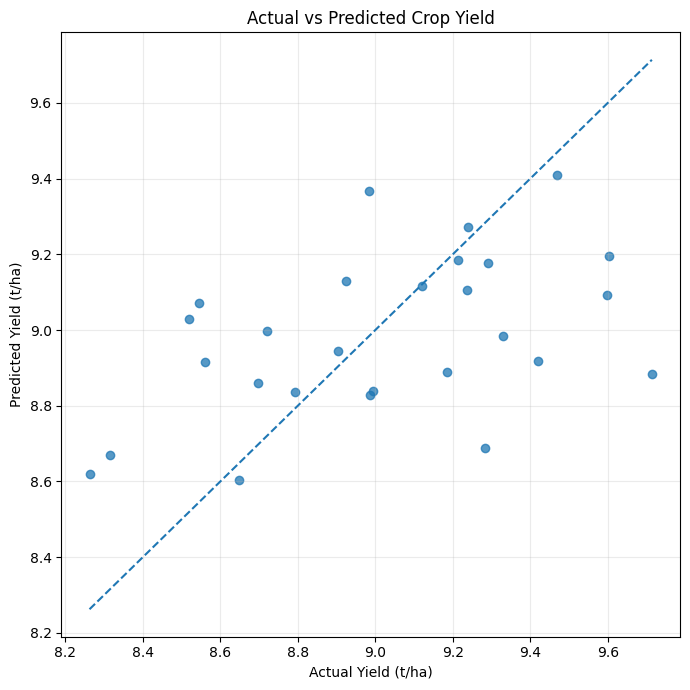

In [ ]:
pred_scaled = model.predict(X_test, verbose=0).ravel()
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE (t/ha)', 'RMSE (t/ha)', 'R²'],
    'Value': [mae, rmse, r2]
})
display(metrics.round(4))

plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=.75)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlabel('Actual Yield (t/ha)'); plt.ylabel('Predicted Yield (t/ha)')
plt.title('Actual vs Predicted Crop Yield')
plt.grid(alpha=.25); plt.tight_layout(); plt.show()

In [ ]:
results = pd.DataFrame({
    'field_id': id_test,
    'actual_yield_t_ha': y_true,
    'predicted_yield_t_ha': y_pred
})
results['absolute_error_t_ha'] = np.abs(results['actual_yield_t_ha'] - results['predicted_yield_t_ha'])
display(results.sort_values('absolute_error_t_ha').head(10).round(3))

,field_id,actual_yield_t_ha,predicted_yield_t_ha,absolute_error_t_ha
8,36,9.121,9.116,0.005
26,167,9.215,9.186,0.029
22,140,9.239,9.273,0.034
3,19,8.903,8.944,0.042
21,139,8.792,8.836,0.043
14,64,8.648,8.605,0.044
1,14,9.468,9.409,0.059
23,141,9.292,9.177,0.115
6,34,9.236,9.106,0.129
24,163,8.993,8.840,0.154


## 7. Save Model for Deployment

The model, feature scaler, target scaler, feature configuration, and sample predictions are saved in `/content/crop_yield_artifacts/`.

In [ ]:
ARTIFACT_DIR = '/content/crop_yield_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model.save(os.path.join(ARTIFACT_DIR, 'crop_yield_lstm.keras'))
joblib.dump(feature_scaler, os.path.join(ARTIFACT_DIR, 'feature_scaler.joblib'))
joblib.dump(target_scaler, os.path.join(ARTIFACT_DIR, 'target_scaler.joblib'))
joblib.dump({'features': FEATURES, 'target': TARGET, 'time_steps': TIME_STEPS},
            os.path.join(ARTIFACT_DIR, 'config.joblib'))
results.to_csv(os.path.join(ARTIFACT_DIR, 'test_predictions.csv'), index=False)
metrics.to_csv(os.path.join(ARTIFACT_DIR, 'metrics.csv'), index=False)

print('Saved artifacts:')
for name in sorted(os.listdir(ARTIFACT_DIR)):
    print(' -', name)

Saved artifacts:
 - config.joblib
 - crop_yield_lstm.keras
 - feature_scaler.joblib
 - metrics.csv
 - target_scaler.joblib
 - test_predictions.csv


## 8. Interactive Prediction for a New Sequence

Enter 8 chronological observations for one field. The model returns the predicted yield in tonnes/hectare.

For a real deployment, replace the example values with observations from satellite/environmental preprocessing.

In [ ]:
# Example sequence: 8 chronological observations.
new_sequence = pd.DataFrame([
    [0.30, 0.25, 0.10, 26.0, 55, 0.40],
    [0.35, 0.29, 0.12, 27.0, 62, 0.42],
    [0.42, 0.35, 0.15, 28.0, 75, 0.45],
    [0.50, 0.41, 0.18, 29.0, 88, 0.48],
    [0.58, 0.47, 0.21, 29.5, 95, 0.51],
    [0.65, 0.53, 0.23, 30.0, 105, 0.54],
    [0.69, 0.57, 0.24, 29.0, 92, 0.55],
    [0.67, 0.55, 0.22, 28.0, 80, 0.53],
], columns=FEATURES)

new_scaled = feature_scaler.transform(new_sequence)
new_X = new_scaled.reshape(1, TIME_STEPS, len(FEATURES)).astype(np.float32)
pred_scaled_new = model.predict(new_X, verbose=0)
pred_yield = target_scaler.inverse_transform(pred_scaled_new)[0, 0]

print(f'Predicted crop yield: {pred_yield:.2f} t/ha')

Predicted crop yield: 8.65 t/ha


## 9. Download the Deployment Artifacts

The following cell creates a ZIP containing the trained LSTM and preprocessing files so they can be downloaded from Colab.

In [ ]:
import shutil
zip_path = shutil.make_archive('/content/crop_yield_lstm_artifacts', 'zip', ARTIFACT_DIR)
print(zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print('If you are not running in Colab, the ZIP is available at:', zip_path)

/content/crop_yield_lstm_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Suggested Presentation Flow

1. **Problem:** crop yield is affected by weather, vegetation condition, and soil moisture over time.
2. **Data:** satellite vegetation indices + environmental observations.
3. **Why LSTM:** it can learn relationships across ordered temporal observations.
4. **Preprocessing:** cleaning, scaling, field-level train/validation/test split, sequence creation.
5. **Model:** stacked LSTM + dropout + dense regression layer.
6. **Evaluation:** MAE, RMSE and R², plus actual-vs-predicted plot.
7. **Deployment:** saved `.keras` model and scaler artifacts.

### Academic note
This notebook is designed as a complete classroom prototype. It does **not** claim that the synthetic dataset represents real satellite measurements. For a final academic submission, document the source, spatial/temporal resolution, preprocessing, and limitations of the real dataset you use.